In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm


## Plot correlations

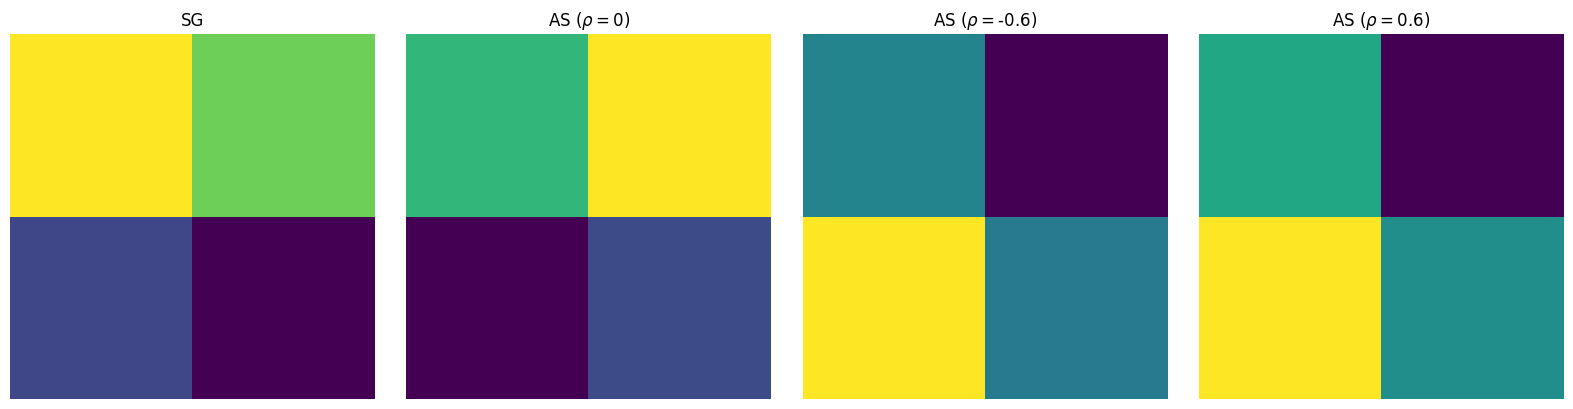

In [3]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 2
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0, -0.6, 0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [19]:
m = SocialGPModel(
    n=n_children + 1,
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.0, -0.6, 0.6]),
    tau_sampling=True, # tau=0.03,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type       tau
Step AgentID                                                          
1    1        (1, 0)  0.409667           0.409667         SG  0.004226
     2        (0, 0) -0.484035          -0.484035         AS  0.004226
     3        (0, 0)  0.488986           0.488986         AS  0.004226
     4        (0, 0)  0.494947           0.494947         AS  0.004226
2    1        (1, 1)  0.329589           0.239256         SG  0.004226
     2        (1, 0)  0.158484          -0.825551         AS  0.004226
     3        (1, 1) -0.484239          -0.495253         AS  0.004226
     4        (1, 1) -0.492545          -0.497598         AS  0.004226
3    1        (1, 0)  0.403266           0.142522         SG  0.004226
     2        (1, 1)  0.479865          -0.845686         AS  0.004226
     3        (0, 0)  0.502064          -0.493190         AS  0.004226
     4        (0, 0)  0.508713          -0.488885         AS  0.004226
4    1        (0, 0)  0.128135          -0.229343         SG  0.004226
     2        (1, 1)  0.509754          -0.835932         AS  0.004226
     3        (0, 0)  0.515520          -0.477670         AS  0.004226
     4        (0, 0)  0.493634          -0.495250         AS  0.004226
5    1        (1, 0)  0.420680          -0.308663         SG  0.004226
     2        (1, 1)  0.510950          -0.824982         AS  0.004226
     3        (0, 0)  0.509521          -0.468149         AS  0.004226
     4        (0, 0)  0.505938          -0.489313         AS  0.004226